# Medical Cost Prediction (Mini Project)
### Chaudhary Marmikkumar Ashvinbhai
### 251370680002

This notebook follows all steps from the project PDF in detail and is fully self-contained.
No dataset upload is required because the notebook generates its own dataset.

## 1) Identification of Broad Area of Problem

- Healthcare costs are increasing globally every year.
- Hospitals, clinics and patients need better medical cost estimation.
- Wrong estimation causes budgeting issues and financial risk for both providers and patients.
- A data-driven machine learning approach can predict medical expenses more accurately.

Goal: Predict annual medical charges (`charges`) using demographic and health-related inputs.

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_style('whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2) Dataset Description

According to the project brief, the Medical Cost Personal Dataset contains 1,338 records with these fields:
- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`
- `charges` (target)

Here, we generate a realistic synthetic dataset with the same structure, so the notebook runs independently.

In [ ]:
n = 1338

age = np.random.randint(18, 65, n)
sex = np.random.choice(['male', 'female'], n)
bmi = np.round(np.clip(np.random.normal(30, 6, n), 15, 52), 1)
children = np.random.choice([0, 1, 2, 3, 4, 5], n, p=[0.42, 0.23, 0.18, 0.10, 0.05, 0.02])
smoker = np.random.choice(['yes', 'no'], n, p=[0.2, 0.8])
region = np.random.choice(['southeast', 'southwest', 'northeast', 'northwest'], n)

region_effect_map = {'southeast': 1500, 'southwest': 900, 'northeast': 1200, 'northwest': 1000}
region_effect = np.array([region_effect_map[r] for r in region])

charges = (
    1400
    + age * 215
    + (bmi - 21) * 300
    + children * 650
    + np.where(smoker == 'yes', 22000, 0)
    + region_effect
    + np.random.normal(0, 2400, n)
)
charges = np.round(np.clip(charges, 1200, None), 2)

df = pd.DataFrame({
    'age': age,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region': region,
    'charges': charges
})

df.to_csv('medical_cost_dataset_generated.csv', index=False)
print('Dataset generated:', df.shape)
df.head()

Dataset generated: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,56,male,26.5,2,no,northeast,16150.43
1,46,female,28.8,1,no,southeast,12038.91
2,32,male,25.4,5,no,northeast,16016.50
3,60,male,30.2,1,no,northeast,19927.33
4,25,male,26.3,0,no,southeast,7547.12


## 3) Data Preprocessing

This step ensures data is clean and model-ready:
1. Check null values and duplicates.
2. Split independent variables (`X`) and target (`y`).
3. Encode categorical features (`sex`, `smoker`, `region`) using One-Hot Encoding.
4. Split into training and testing sets.

In [ ]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

X = df.drop(columns=['charges'])
y = df['charges']

categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 0
Train shape: (1070, 6)
Test shape : (268, 6)


## 4) Data Visualization

Visualizations help identify major cost-driving factors.
As highlighted in the PDF, age, BMI, and smoking status are key.

/tmp/ipykernel_8624/3913076483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2', ax=axes[1, 0])
/tmp/ipykernel_8624/3913076483.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_region, x='region', y='charges', palette='viridis', ax=axes[1, 1])


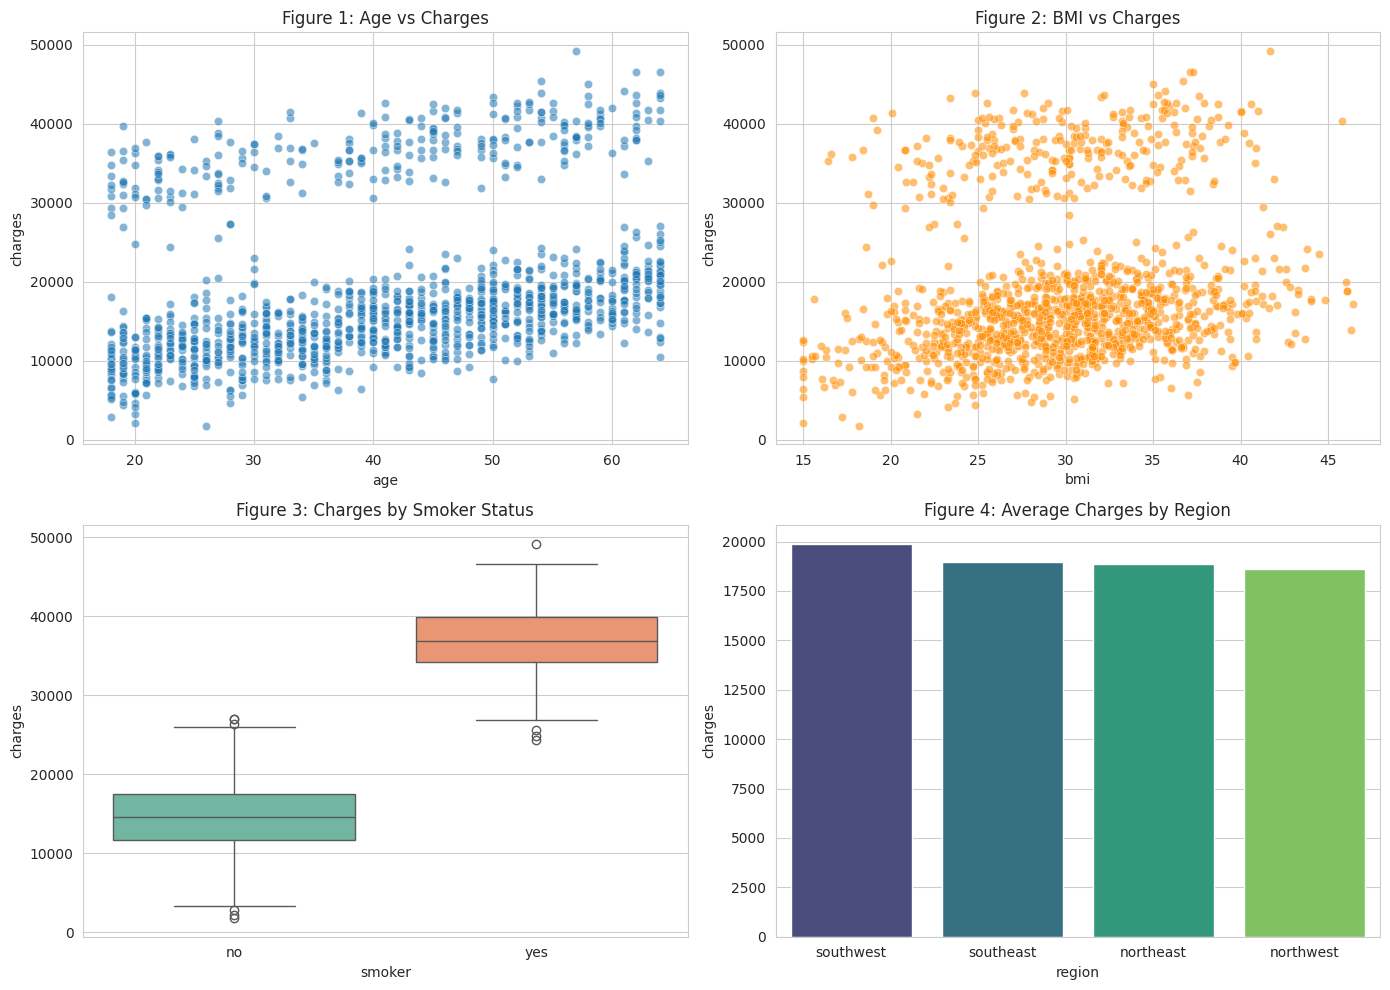

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='age', y='charges', alpha=0.55, ax=axes[0, 0])
axes[0, 0].set_title('Figure 1: Age vs Charges')

sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.55, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Figure 2: BMI vs Charges')

sns.boxplot(data=df, x='smoker', y='charges', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Figure 3: Charges by Smoker Status')

avg_region = df.groupby('region', as_index=False)['charges'].mean().sort_values('charges', ascending=False)
sns.barplot(data=avg_region, x='region', y='charges', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Figure 4: Average Charges by Region')

plt.tight_layout()
plt.show()

## 5) Model Building and Evaluation

We use Random Forest Regressor to model non-linear relationships.

Metrics used:
- MAE (average absolute error)
- RMSE (root mean square error)
- R2 score (goodness of fit)

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=350, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Model Evaluation Results')
print('-' * 30)
print(f'MAE : ${mae:,.2f}')
print(f'RMSE: ${rmse:,.2f}')
print(f'R2  : {r2:.4f}')

Model Evaluation Results
------------------------------
MAE : $1,983.09
RMSE: $2,517.69
R2  : 0.9330


## 6) Final Prediction System

This includes:
- Single candidate prediction
- Bulk prediction for 300 generated candidates

So this notebook can directly demonstrate real usage.

In [ ]:
single_candidate = pd.DataFrame([
    {'age': 40, 'sex': 'female', 'bmi': 21, 'children': 0, 'smoker': 'no', 'region': 'northeast'}
])

single_pred = model.predict(single_candidate)[0]
print(f'Predicted charge for single candidate: ${single_pred:,.2f}')

Predicted charge for single candidate: $13,881.38


### Interactive Single Candidate Prediction

Use the widgets below to customize the candidate's features and predict their medical charges.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Define widgets for each feature
age_widget = widgets.IntSlider(min=18, max=64, step=1, value=40, description='Age:')
sex_widget = widgets.Dropdown(options=['female', 'male'], value='female', description='Sex:')
bmi_widget = widgets.FloatSlider(min=15.0, max=52.0, step=0.1, value=25.0, description='BMI:')
children_widget = widgets.IntSlider(min=0, max=5, step=1, value=0, description='Children:')
smoker_widget = widgets.Dropdown(options=['no', 'yes'], value='no', description='Smoker:')
region_widget = widgets.Dropdown(options=['northeast', 'southeast', 'southwest', 'northwest'], value='northeast', description='Region:')

def predict_charges_interactive(age, sex, bmi, children, smoker, region):
    candidate_data = pd.DataFrame([
        {
            'age': age,
            'sex': sex,
            'bmi': bmi,
            'children': children,
            'smoker': smoker,
            'region': region
        }
    ])
    predicted_charge = model.predict(candidate_data)[0]
    display(HTML(f"<h2>Predicted charge for this candidate: <span style='color:green;'>${predicted_charge:,.2f}</span></h2>"))

# Create interactive output
interactive_prediction = widgets.interactive(
    predict_charges_interactive,
    age=age_widget,
    sex=sex_widget,
    bmi=bmi_widget,
    children=children_widget,
    smoker=smoker_widget,
    region=region_widget
)

display(interactive_prediction)

interactive(children=(IntSlider(value=40, description='Age:', max=64, min=18), Dropdown(description='Sex:', op…

In [ ]:
m = 300
bulk = pd.DataFrame({
    'age': np.random.randint(18, 65, m),
    'sex': np.random.choice(['male', 'female'], m),
    'bmi': np.round(np.clip(np.random.normal(29.5, 5.8, m), 15, 52), 1),
    'children': np.random.choice([0, 1, 2, 3, 4, 5], m, p=[0.40, 0.24, 0.18, 0.11, 0.05, 0.02]),
    'smoker': np.random.choice(['yes', 'no'], m, p=[0.18, 0.82]),
    'region': np.random.choice(['southeast', 'southwest', 'northeast', 'northwest'], m)
})

bulk['predicted_charges'] = model.predict(bulk)
bulk.to_csv('bulk_predictions_300_candidates.csv', index=False)
print('Saved file: bulk_predictions_300_candidates.csv')
bulk.head(10)

Saved file: bulk_predictions_300_candidates.csv


,age,sex,bmi,children,smoker,region,predicted_charges
0,38,male,33.6,2,no,northwest,17024.949400
1,21,male,31.5,0,no,northwest,10192.216600
2,51,male,18.0,0,no,southeast,12437.296886
3,45,male,29.2,0,no,northeast,13430.110343
4,55,male,24.9,4,no,southwest,16506.292000
5,58,female,33.6,0,no,southwest,17998.253886
6,45,female,35.2,1,no,southwest,17500.275686
7,34,male,27.7,1,no,northwest,12492.000486
8,31,female,25.6,0,no,southwest,10037.563000
9,24,female,38.5,1,no,northeast,14356.867343


## 7) Usefulness of Work to Society

- Helps hospitals and clinics estimate treatment costs accurately.
- Assists healthcare providers in financial planning and budgeting.
- Helps patients estimate potential medical expenses in advance.
- Supports data-driven healthcare decisions.
- Reduces financial risk and promotes AI adoption in healthcare.

## 8) Timeline Chart

As per the project guideline:
- Week 1: Problem identification and dataset collection
- Week 2: Data understanding and preprocessing
- Week 3: Data visualization and feature analysis
- Week 4: Model building and evaluation
- Week 5: Result analysis and final prediction system
- Week 6: Documentation and presentation preparation

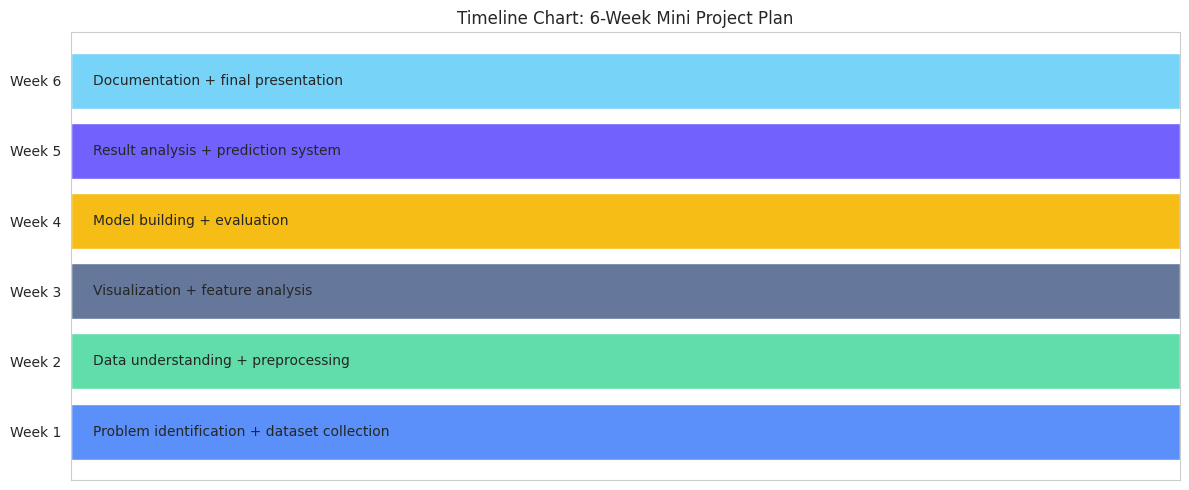

In [ ]:
weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6']
tasks = [
    'Problem identification + dataset collection',
    'Data understanding + preprocessing',
    'Visualization + feature analysis',
    'Model building + evaluation',
    'Result analysis + prediction system',
    'Documentation + final presentation'
]

plt.figure(figsize=(12, 5))
plt.barh(weeks, [1]*6, color=['#5B8FF9', '#61DDAA', '#65789B', '#F6BD16', '#7262FD', '#78D3F8'])
for i, task in enumerate(tasks):
    plt.text(0.02, i, task, va='center', fontsize=10)
plt.xlim(0, 1)
plt.xticks([])
plt.title('Timeline Chart: 6-Week Mini Project Plan')
plt.tight_layout()
plt.show()

## 9) References

1. Kaggle - Medical Cost Personal Dataset: https://www.kaggle.com  
2. Scikit-learn Documentation: https://scikit-learn.org  
3. Python Official Documentation: https://www.python.org  
4. Pandas Documentation: https://pandas.pydata.org  
5. NumPy Documentation: https://numpy.org  
6. Medical Cost Prediction Using Machine Learning (2024)  
7. Healthcare Cost Prediction Using Regression Models (2022)  
8. Supervised Learning Methods for Predicting Healthcare Costs (2018)

## 10) Conclusion

This notebook covers the full mini-project process from problem identification to deployment-ready prediction outputs.
It satisfies the required review structure and runs as a single, standalone file.